# TO DO

- doublecheck remaining functions in the workshopfile to be added (from section "ExcludeVector" downwards)
- asArea=True doenst work (cf. 01_placement file)
- Finalize short introduction  
- check which data might be still missing (gis_osm data..?)

? MIssing Data files:    
    ? gwa3_250_wind-speed_100m.NRW.tif" # shared data cluster
    ? axialDirection=f(ERA5_wind_direction_100m_mean.tiff) # gk, clipping
    ? is temp directory actually ingoing data? If yes, then merge into /data
    ? ensure relative paths only
    ? Cut WDPA_Jul2020-shapefile-polygons.shp (4 GB alternative) [JM] got them from Julia (check Reskit comment from Chris)


? srs = LAEA vs 3035 ? [@chris]d

@others
- workshop is old and functions are not uptodate anymore (excludeVectorType(forceMaskShape=True))
- workaround for ec.distributeItems( separation=1000, asArea=True)
- Placement algorythm builts up on Prior datasets apparently
- exclude this firstly and finish work done until now

NEXT: Restructure this notebook, cut data smaller


In the following everything from 00_basic_workflow.ipynb, thats not yet used in 00_basic_workflow_new.ipynb or 01_Placement_algorithm_new.ipynb, is listed

# Introduction

This workbook presents multiple more functions of GLAES:

### Overview:
1) Using exclusion sets
2) Reinitializing previous ExclusionCalculators
3) Drawing with basemaps
4) Accessing grid information
5) Considering region boundary effects with padExtent 
6) excludeRasterType with ranges for clc classes
7) IncludeRasterType
8) Working with Digital Elevation Maps DEM Mosaics to exclude Raster

In [42]:
# Import GLAES
import glaes as gl
import geokit as gk
import numpy as np
import matplotlib.pyplot as plt

In [43]:
# Choose a region to operate on (Here, a predefined region for Aachen, Germany is used)
regionPath = gl._test_data_["aachenShapefile.shp"]

clc_path = gl._test_data_["clc-aachen_clipped.tif"]

# Function to initialize new ExclusionCalculator object
ec = gl.ExclusionCalculator(regionPath, srs=3035, pixelRes=100)

# 1. Working with Exclusion Sets

In [44]:
import pandas as pd

# exclusion_set = pd.read_csv("sample_exclusion_set.csv")
exclusion_set = pd.read_csv(gl._test_data_["sample_exclusion_set.csv"])
exclusion_set

,name,type,value,buffer
0,clc,raster,[12-22],NaN
1,clc,raster,[1-2],1000.0
2,osm_roads,vector,type='motorway' OR type='primary' OR type='trunk',200.0


Excluding Raster clc with value [12-22], buffer None, mode exclude, and invert False
c:\Users\j.mutke\AppData\Local\miniforge3\envs\glaes\lib\site-packages\geokit\core\regionmask.py:958: UserWarning: Multiprocessing has been set to 'False' because it is not available for Windows or Mac. To deactivate this warning, please set the multiProcess variable to False. On Windows and Mac, new processes must be spawned, which requires the serialisation of the method to be executed via multiprocessing. However, Geokit contains objects that cannot be serialised by Pickle. On Linux, however, new processes are inherited and no serialisation is required.
  warn(multi_processing_warning_message)


Memory useage during calc: 421.671875 MB


Excluding Raster clc with value [1-2], buffer 1000.0, mode exclude, and invert False


Memory useage during calc: 421.671875 MB


Excluding Vector osm_roads with where-statement "type='motorway' OR type='primary' OR type='trunk'", buffer 200.0, mode exclude, and invert False 
c:\Users\j.mutke\AppData\Local\miniforge3\envs\glaes\lib\site-packages\geokit\core\regionmask.py:1560: UserWarning: Memory efficient multiProcess failed, returning to safe linear processing.
  warn(


Memory useage during calc: 434.0546875 MB


Done!


<Axes: >

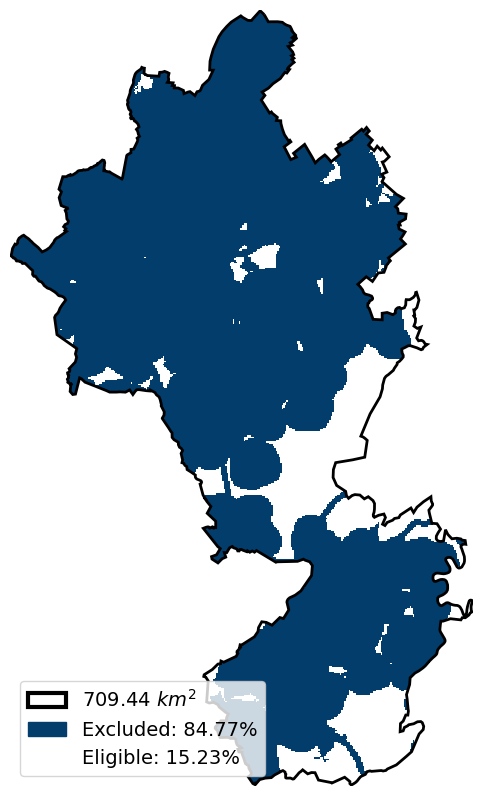

In [45]:
## Make a new ExclusoinCalculator
ec = gl.ExclusionCalculator(regionPath, srs=3035, pixelRes=100)

## Apply exclusions from the given set
ec.excludeSet(
    exclusion_set=exclusion_set,
    clc=gl._test_data_["clc-aachen_clipped.tif"],
    osm_roads=gl._test_data_["aachenRoads.shp"],
)

## Draw result
ec.draw()

# 2. Reinitialize an ExclusionCalculator from a pre-computed result

c:\Users\j.mutke\AppData\Local\miniforge3\envs\glaes\lib\site-packages\geokit\core\regionmask.py:958: UserWarning: Multiprocessing has been set to 'False' because it is not available for Windows or Mac. To deactivate this warning, please set the multiProcess variable to False. On Windows and Mac, new processes must be spawned, which requires the serialisation of the method to be executed via multiprocessing. However, Geokit contains objects that cannot be serialised by Pickle. On Linux, however, new processes are inherited and no serialisation is required.
  warn(multi_processing_warning_message)


Memory useage during calc: 430.4375 MB


<Axes: >

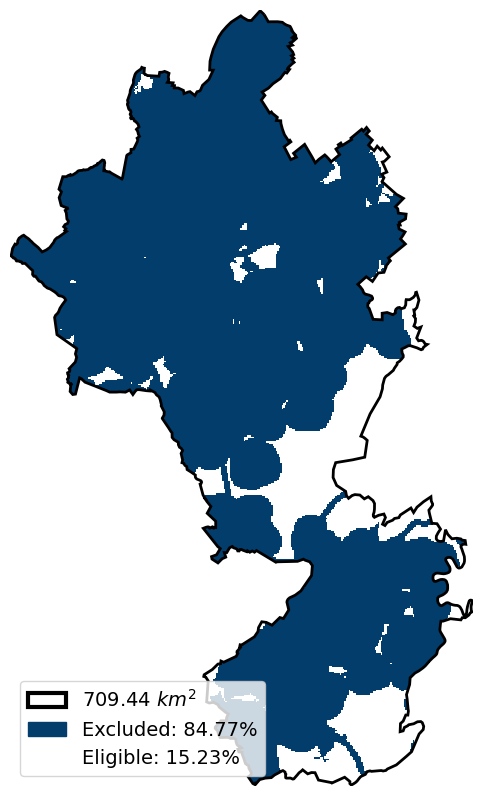

In [46]:
## Set the initial value to those we computed previously. This is particularly useful if the original calculation took a while
ec = gl.ExclusionCalculator(regionPath, srs=3035, pixelRes=100, initialValue="tmp/aachens_best_pv_spots.tif")

## Draw the result
ec.draw()

# 3. Draw exclusions with a basemap

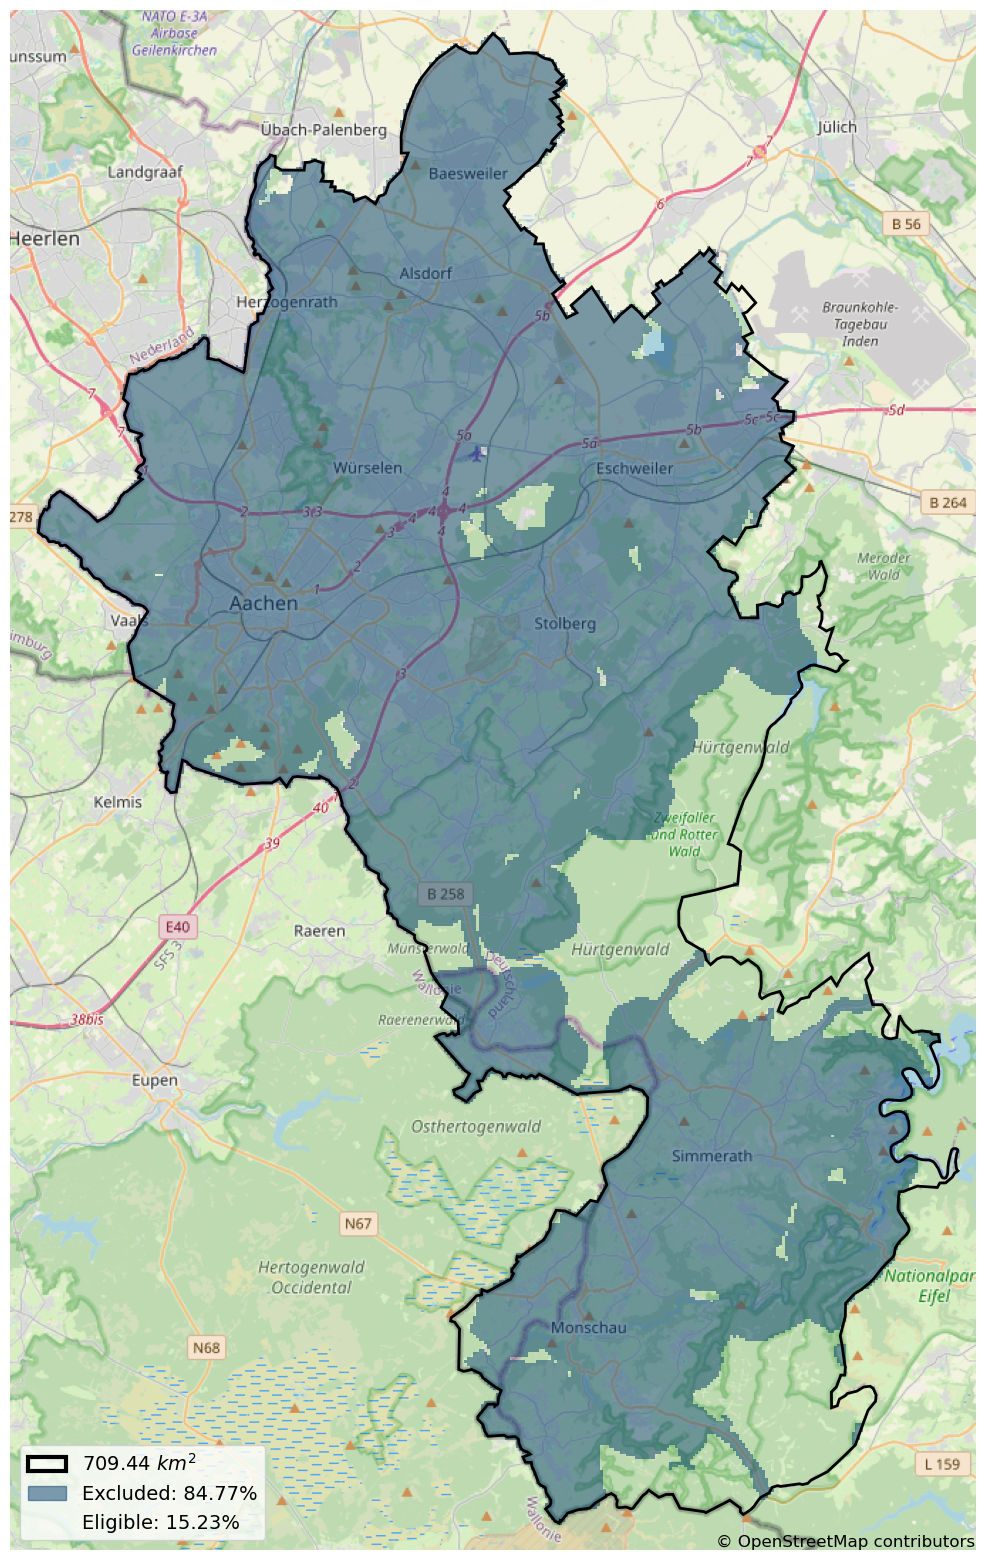

In [47]:
# Be careful to not use a too-high zoom level!
# Also don't forget about using the right attribution

ax = ec.drawWithSmopyBasemap(zoom=11, figsize=(40, 20))

# 4. Access grid information of the ExclusionCalculator

In [48]:
ec = gl.ExclusionCalculator(regionPath, srs=3035, pixelRes=100)

# Bounding box: smallest rectangle around the region (units: meter, refering to srs)
ec.region.extent
# Mask: Pixel grid inside bounding box, according to pixelRes (True = inside regiion, False = outside region)
ec.region.mask
# Get shape of the mask (rows, columns)
ec.region.mask.shape

(509, 304)

# 5. Considering region boundary effects with padExtent 

In [49]:
# padExtent adds a padding buffer around your region’s bounding box so calculations near the border don’t miss features just outside the region.
# Without padding, buffers (e.g., a 3 km exclusion zone) that extend beyond the region get cut off at the boundary, so edge effects are computed incorrectly.
# With padExtent, you include enough surrounding raster to fully apply those buffers—e.g., a road 1 km outside the boundary can still correctly exclude the
# 2 km of area inside the region that falls within a 3 km buffer. Because of this padding, the region extent coordinates change, and the mask/grid shape 
# (size) increases.

ec = gl.ExclusionCalculator(
    region=regionPath, 
    srs=3035, 
    pixelRes=100,
    padExtent=0
    )

print(ec.region.extent)
print(ec.region.mask.shape)

ec = gl.ExclusionCalculator(
    region=regionPath, 
    srs=3035, 
    pixelRes=100,
    padExtent=2000
    )

print(ec.region.extent)
print(ec.region.mask.shape)

(4037300.00000,3049300.00000,4067700.00000,3100200.00000)
(509, 304)
(4035300.00000,3047300.00000,4069700.00000,3102200.00000)
(549, 344)


# 6. excludeRasterType with ranges for clc classes

Memory useage during calc: 482.17578125 MB


<Axes: >

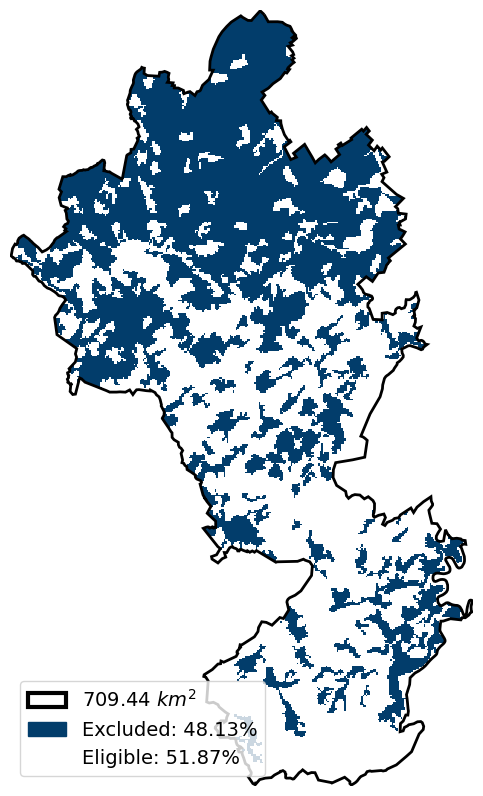

In [50]:
ec = gl.ExclusionCalculator(regionPath, srs=3035, pixelRes=100)

ec.excludeRasterType(source=clc_path, value="[1-2],12,[21-23]") # syntax for using ranges
ec.draw()

# 7. Alternative filter  (include, invert, initialValue)

Memory useage during calc: 482.2734375 MB


<Axes: >

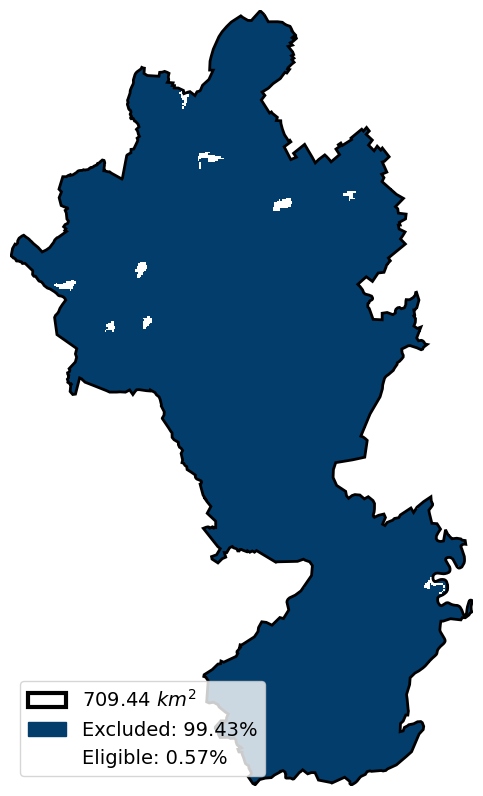

In [51]:
# use include mode to start with full exclusion and only include the specified clc classes to be eligible

ec = gl.ExclusionCalculator(
        region=regionPath,
        srs=3035, 
        pixelRes=100,
        initialValue=False
        )

ec.excludeRasterType(source=clc_path, value=11, mode="include")

ec.draw()

Memory useage during calc: 449.44921875 MB


0.565234551195309

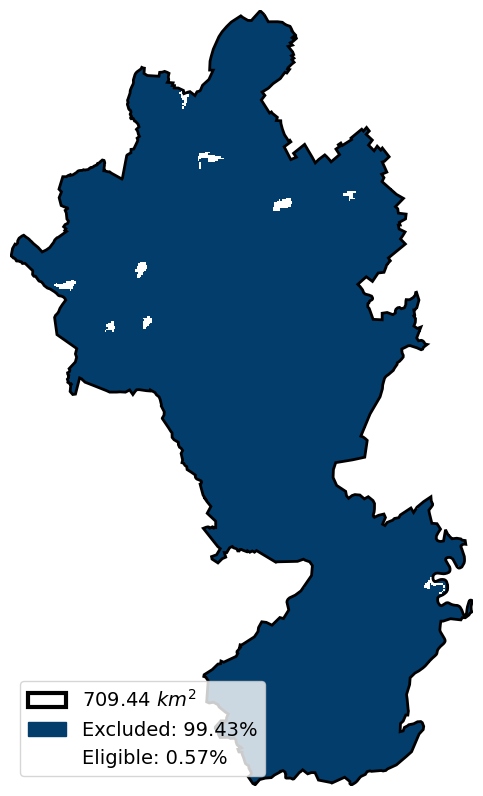

In [52]:
# invert excludeRasterType
ec = gl.ExclusionCalculator(
        region=regionPath,
        srs=3035, 
        pixelRes=100,
        initialValue=False
        )

ec.excludeRasterType(source=clc_path, value=11, mode="include", invert=False)

ec.draw()
ec.percentAvailable

Memory useage during calc: 453.265625 MB


<Axes: >

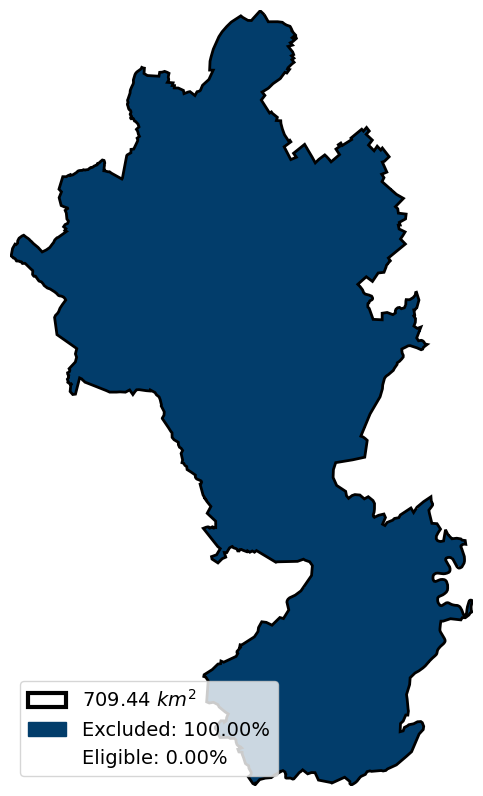

In [53]:
ec.excludeRasterType(source=clc_path, value="[1-2],12,[21-23]", invert=True)

ec.draw()

# 8. Working with DEM Mosaics to exclude Raster

<class 'osgeo.gdal.Dataset'>


AxHands(ax=<Axes: >, handles=<matplotlib.image.AxesImage object at 0x0000028C0E754220>, cbar=<matplotlib.colorbar.Colorbar object at 0x0000028C1870E080>)

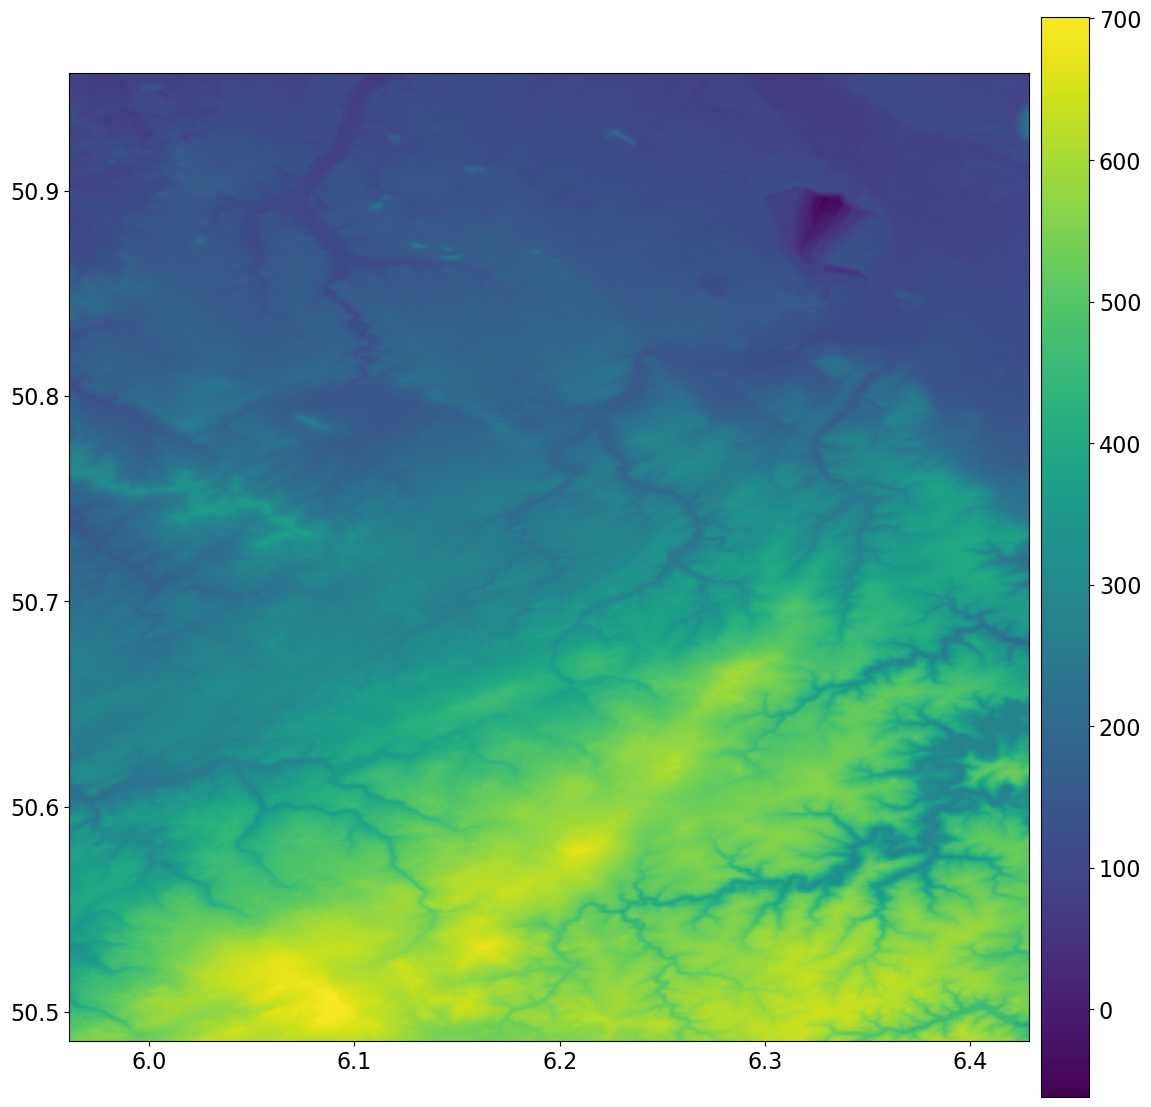

In [54]:
# Create an elevation mosaic heatmap from digital elevation model (DEM) files. DEMs are raster 
# grids where each pixel stores the ground elevation, forming a digital model of the terrain’s 
# height. Data can be found and downloaded for other regions from https://dwtkns.com/srtm30m . 
# Note, that multiple files might be necessary if your region is large or spans multiple tiles. 
# All files put into .rasterMosaic() will be merged to a single raster mosaic covering the entire region. 

import geokit as gk

dem_raster = ec.region.extent.rasterMosaic(r"C:\Users\j.mutke\Desktop\GLAES_Github\glaes\glaes\test\data\*.hgt")
print(type(dem_raster)) # multiple DEM files merged into a single raster mosaic
gk.drawRaster(dem_raster)


Memory useage during calc: 491.15234375 MB


<Axes: >

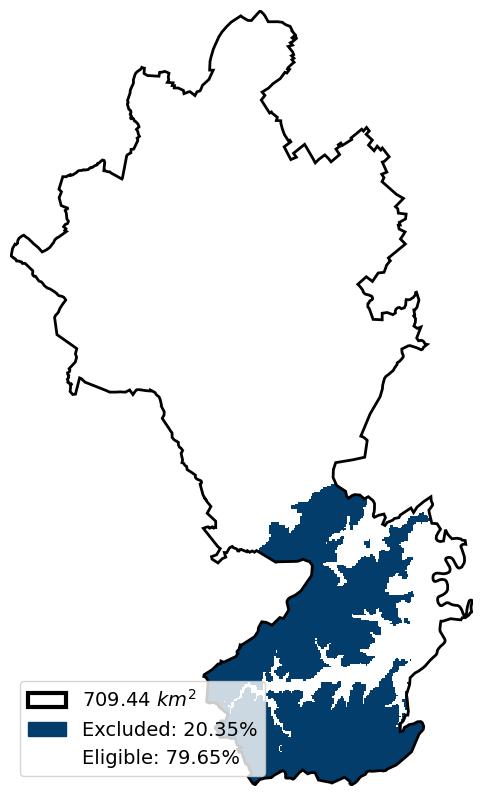

In [55]:
# exclude areas above 500m elevation. Note, that here the hilly Eiffel region is mainly exluded in the region's south.
ec = gl.ExclusionCalculator(regionPath, srs=3035, pixelRes=100)
ec.excludeRasterType(dem_raster, value="(500-]", resampleAlg="mode")
ec.draw()

Memory useage during calc: 482.8984375 MB


<Axes: >

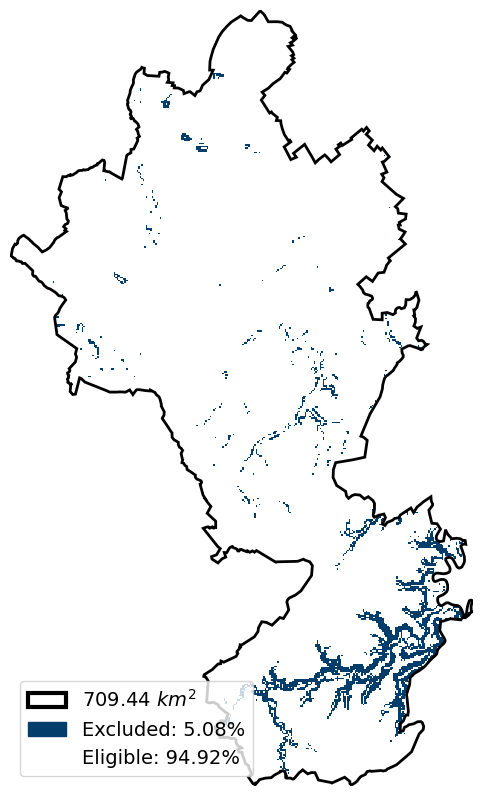

In [56]:
# Exclude Raster - DEM Gradient Mosaic. Exlude slopes above 15 degrees.

dem_gradiate_raster = gk.raster.mutateRaster(
    source=gk.raster.gradient(                          # computes the gradient (slope) of a raster
            source=dem_raster,
            factor="latlonToM"),                        # factor to convert lat/lon degrees to meters
    processor=lambda x: np.degrees(np.arctan(x))        # convert gradient to degrees
)

ec = gl.ExclusionCalculator(regionPath, srs=3035, pixelRes=100)
ec.excludeRasterType(dem_gradiate_raster, value=(15, None), resampleAlg="mode")

ec.draw()

Memory useage during calc: 486.70703125 MB


<Axes: >

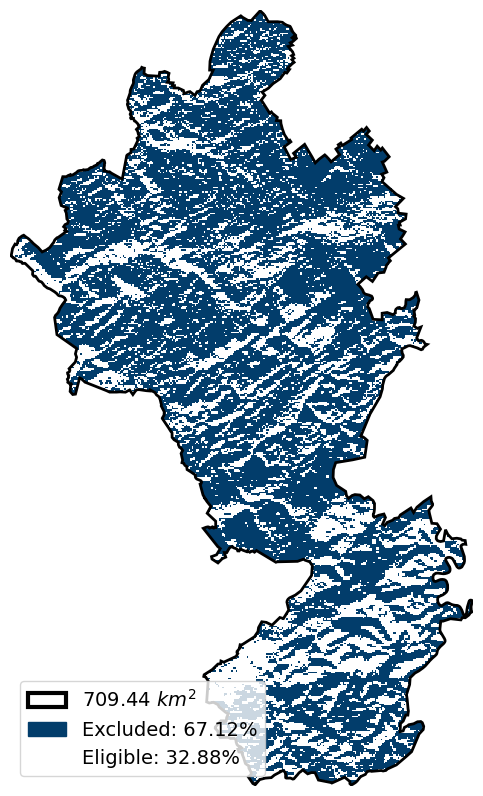

In [57]:
# Exlude slopes with north orientation, as north facing slopes receive less radiation.

dem_ns_gradiate_raster = gk.raster.mutateRaster(
    source=gk.raster.gradient(
            source=dem_raster,
            factor="latlonToM",
            mode="north-south"),
    processor=lambda matrix: np.degrees(np.arctan(matrix))
)

ec = gl.ExclusionCalculator(regionPath, srs=3035, pixelRes=100)

# exclude all north facing slopes (values > 0 degrees)
ec.excludeRasterType(dem_ns_gradiate_raster, value=(0, None), resampleAlg="mode")

ec.draw()

# 9. ExcludeVectorType (In Progress)

In [58]:
def make_new_ec(**kwargs):
    
    ec = gl.ExclusionCalculator(
        region=gk._test_data_['aachenShapefile.shp'],
        srs="LAEA", 
        pixelRes=50,
        padExtent=5000,
        **kwargs)
    return ec

c:\Users\j.mutke\AppData\Local\miniforge3\envs\glaes\lib\site-packages\geokit\core\regionmask.py:1560: UserWarning: Memory efficient multiProcess failed, returning to safe linear processing.
  warn(


<Axes: >

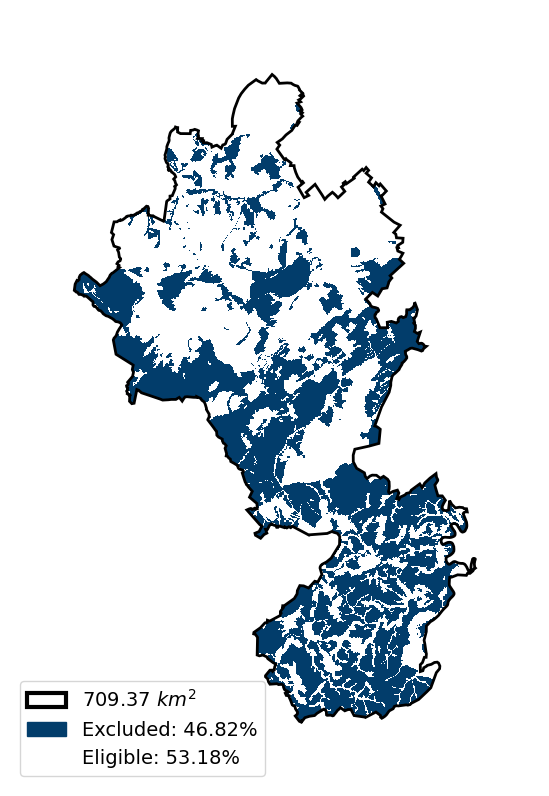

In [59]:
#  Exclude Vector - Simple source w/ where clause

ec = make_new_ec()
ec.excludeVectorType(
    source=r"C:/Users/j.mutke/Desktop/GLAES_Github/glaes/Examples/data/WDPA_aachen_bbox.shp",
    where="IUCN_CAT='V'",
)

ec.draw()

Computing intermediate exclusion file: ./intermediate_files/wdpa_V.tif
Overwriting previous intermediate exclusion file: ./intermediate_files/wdpa_V.tif. The following difference in intermediate metadata was found: 
(source: 7811156fe552bf206c5196f2c8fbe47550b0dd7d9a06b4aa5092d43d806ef71b / c3be8a58b1da1a47be4bf3d2f3396573b9435b14e2aa9cc57fb10b60ddc23e9d); 
(SourcePath (not considered in metadata comparison, FYI only): C:/Users/j.mutke/Desktop/GLAES_Github/glaes/Examples/data/WDPA_Feb2020-shapefile-polygons-aachen.shp / C:/Users/j.mutke/Desktop/GLAES_Github/glaes/Examples/data/WDPA_aachen_bbox.shp); 
(old/new intermediate))
c:\Users\j.mutke\AppData\Local\miniforge3\envs\glaes\lib\site-packages\geokit\core\regionmask.py:1560: UserWarning: Memory efficient multiProcess failed, returning to safe linear processing.
  warn(


Memory useage during calc: 510.421875 MB


<Axes: >

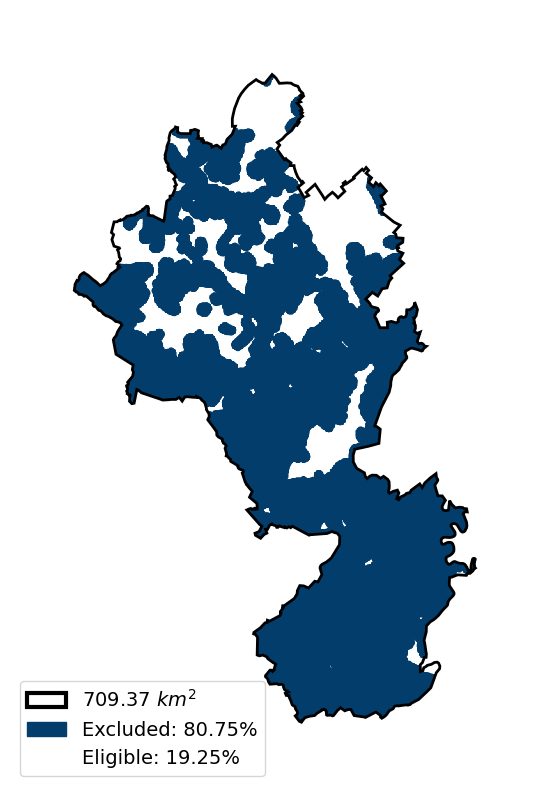

In [60]:
# Exclude Vector - resolutionDiv
ec = make_new_ec()

# ec.excludeVectorType(
    # source=r"C:/Users/j.mutke/Desktop/GLAES_Github/glaes/Examples/data/WDPA_Feb2020-shapefile-polygons.shp",
    # resolutionDiv=8,
# )

ec.excludeVectorType(
    source=r"C:/Users/j.mutke/Desktop/GLAES_Github/glaes/Examples/data/WDPA_aachen_bbox.shp",
    where="IUCN_CAT='V'",
    buffer=400,
    resolutionDiv=8,
    intermediate="./intermediate_files/wdpa_V.tif"
)
ec.draw()

AxHands(ax=<Axes: >, handles=<matplotlib.image.AxesImage object at 0x0000028C0E7A5E70>, cbar=<matplotlib.colorbar.Colorbar object at 0x0000028C0E7A7550>)

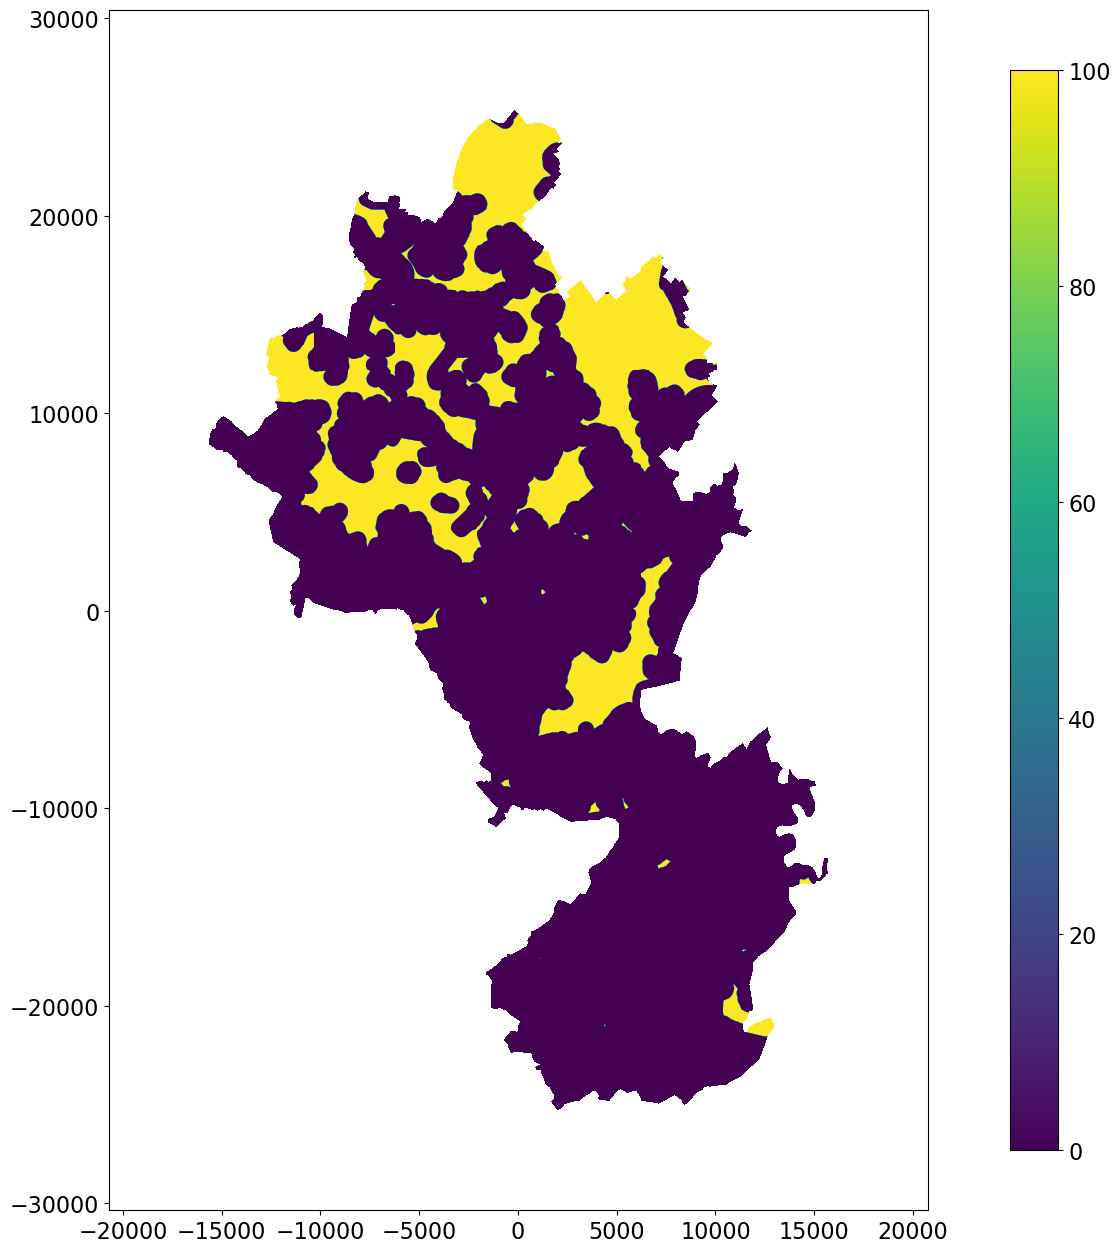

In [61]:
gk.drawRaster("./intermediate_files/wdpa_V.tif")

In [62]:
ec.save?

Signature: ec.save(output, threshold=None, **kwargs)
Docstring:
Save the current availability matrix to a raster file

Output will be a byte-valued raster with the following convention:
    0     -> unavailable
    1..99 -> Semi-available
    100   -> fully eligibile
    255   -> "no data" (out of region)

Parameters:
-----------
output : str
    The path of the output raster file
    * Must end in ".tif"

threshold : float; optional
    The acceptable threshold indicating an available pixel
    * Use this to process the availability matrix before saving it (will
      save a little bit of space)

kwargs:
    * All keyword arguments are passed on to a call to
      geokit.RegionMask.createRaster
    * Most notably:
        - 'dtype' is used to define the data type of the resulting raster
        - 'overwrite' is used to force overwrite an existing file
File:      c:\users\j.mutke\appdata\local\miniforge3\envs\glaes\lib\site-packages\glaes\core\exclusioncalculator.py
Type:      method

In [63]:
ec.save("tmp/test_resolution_div_8.tif")

'tmp/test_resolution_div_8.tif'

# 10 Visualization Methods (Smopy)

<Axes: >

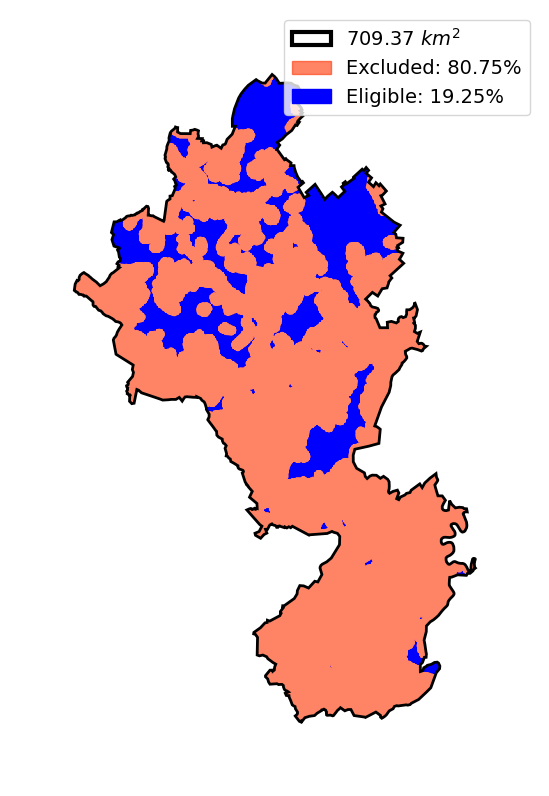

In [64]:
ec.draw(
    goodColor="blue",
    excludedColor=(1.0, 0.2, 0.0, 0.6),
    legendargs={'loc': 'upper right'},)

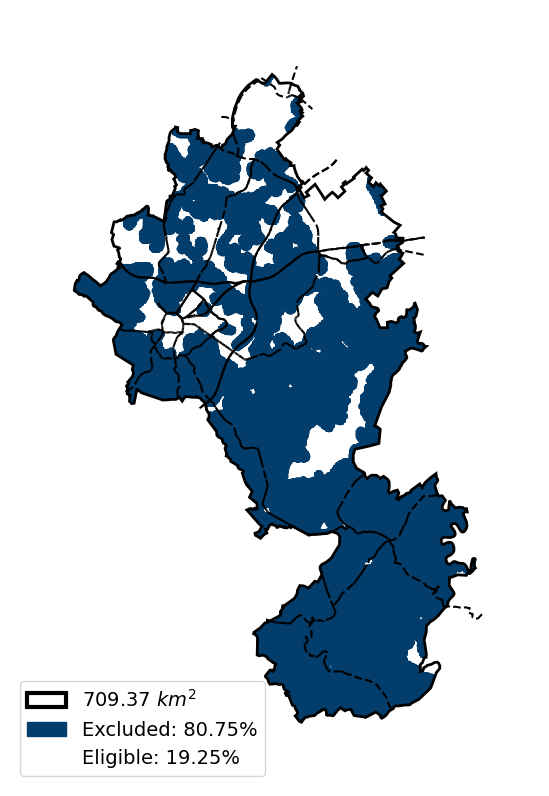

In [65]:
ax = ec.draw()
roads = gk.vector.extractFeatures(r"C:/Users/j.mutke/Desktop/GLAES_Github/glaes/glaes/test/data/aachenRoads.shp", 
                                  where="type='motorway' OR type='primary' OR type='trunk'",
                                  geom=ec.region.geometry)
gk.drawGeoms(roads, ax=ax, color='k', linestyle="--", srs=ec.region.srs)
plt.show()

In [66]:
roads.type.unique()

array(['primary', 'motorway'], dtype=object)

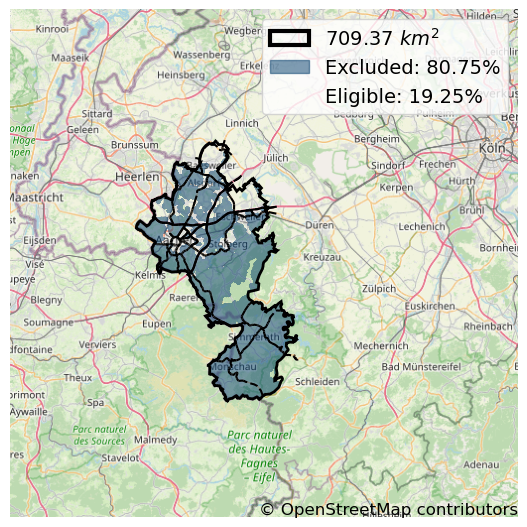

In [67]:
# Draw with Smopy
## Importance of attribution statement!!

ax = ec.drawWithSmopyBasemap(
    zoom=9,
    legendargs={'loc': 'upper right'},)
gk.drawGeoms(roads, ax=ax, color='k', linestyle="--", srs=gk.srs.EPSG3857)

plt.show()

In [68]:
ec.drawWithSmopyBasemap?

Signature:
ec.drawWithSmopyBasemap(
    zoom=4,
    excludedColor=(0.00784313725490196, 0.23921568627450981, 0.4196078431372549, 0.5019607843137255),
    ax=None,
    figsize=None,
    smopy_kwargs={'attribution': '© OpenStreetMap contributors', 'attribution_size': 12},
    **kwargs,
)
Docstring:
This wrapper around the original ExclusionCalculator.draw function adds a basemap bethind the drawn eligibility map

NOTE:
* The basemap is drawn using the Smopy python package. See here: https://github.com/rossant/smopy
* Be careful to adhere to the usage guidelines of the chosen tile source
    - By default, this source is OSM. See here: https://wiki.openstreetmap.org/wiki/Tile_servers

!IMPORTANT! If you will publish any images drawn with this method, it's likely that the tile source
will require an attribution to be written on the image. For example, if using OSM tile (the default),
you have to write "© OpenStreetMap contributors" clearly on the map. But this is different for each
tile sou

# Miscellaneous

In [69]:
# Exclude Raster - resolutionDiv
# Exclude Raster - prewarp
# Exclude Raster - resampleAlg -> "Down sampling": near,bilinear,cubic  "upsampling":average,mode,max,min

# placement stuff to be added? Last section from workshop file..

In [70]:
# # Clip WDPA files smaller with geokit

# # Check WDPA Ausdehnung. Man sieht, dass es global ist.
# import geokit as gk

# pfad = r"C:data\WDPA_Feb2020-shapefile-polygons.shp"

# info = gk.vector.vectorInfo(pfad)
# print("Anzahl Objekte:", info.count)
# print("Koordinatenbezugssystem:", info.srs)
# print("Ausdehnung:", getattr(info, "bounds", None))
# print("xMin, yMin, xMax, yMax:", getattr(info, "xMin", None), getattr(info, "yMin", None),
#                                getattr(info, "xMax", None), getattr(info, "yMax", None))

In [71]:
# # check region that i need
# ext = ec.region.extent
# print("Bounding Box (EPSG:3035):")
# print("xMin, yMin, xMax, yMax =", ext.xMin, ext.yMin, ext.xMax, ext.yMax)

# ext_ll = ext.castTo(gk.srs.EPSG4326)
# print("Bounding Box (Lat/Lon):", ext_ll.xyXY)

In [72]:
# from osgeo import gdal
# # clip
# # 
# # # schneidet auf Region-Bereich zu (schnell, reduziert massiv)
# wdpa = r"data/WDPA_Feb2020-shapefile-polygons.shp"
# ec = gl.ExclusionCalculator(regionPath, srs=3035, pixelRes=100)
# wdpa_local = ec.region.mutateVector(wdpa, regionPad=0)

# # speichern: GeoPackage ist 1 Datei (besser für Git als Shapefile)
# gdal.VectorTranslate("WDPA_Feb2020-shapefile-polygons-aachen.shp", wdpa_local, format="ESRI Shapefile")

In [73]:
# local = r"WDPA_Feb2020-shapefile-polygons-aachen.shp"  # anpassen

# info = gk.vector.vectorInfo(local)
# print("Anzahl Objekte:", info.count)
# print("Koordinatenbezugssystem:", info.srs)
# print("Ausdehnung (xMin, yMin, xMax, yMax):", info.xMin, info.yMin, info.xMax, info.yMax)

In [74]:

# wdpa_path = r"data/WDPA_Feb2020-shapefile-polygons.shp"

# print("WDPA Koordinatensystem:")
# print(gk.vector.vectorInfo(wdpa_path).srs)

# print("\nRegion Koordinatensystem:")
# print(gk.vector.vectorInfo(regionPath).srs)

In [75]:
# from osgeo import gdal

# wdpa = r"data/WDPA_Feb2020-shapefile-polygons.shp"
# west, south, east, north = 5.902234829691196, 50.44905286821326, 6.492645736818313, 50.995522163958576

# opts = gdal.VectorTranslateOptions(
#     format="ESRI Shapefile",
#     spatFilter=(west, south, east, north)  # (xMin, yMin, xMax, yMax) in Grad
# )

# gdal.VectorTranslate("WDPA_aachen_bbox.shp", wdpa, options=opts)

In [76]:
# info = gk.vector.vectorInfo("data/WDPA_aachen_bbox.shp")
# print("Objekte:", info.count)
# print("Ausdehnung:", info.xMin, info.yMin, info.xMax, info.yMax)

In [77]:
# opts2 = gdal.VectorTranslateOptions(
#     format="ESRI Shapefile",
#     dstSRS="EPSG:3035"
# )

# gdal.VectorTranslate("data/WDPA_aachen_3035.shp", "WDPA_aachen_bbox.shp", options=opts2)

In [78]:
# print(gk.vector.vectorInfo("data/WDPA_aachen_3035.shp").srs)
# print("Objekte:", gk.vector.vectorInfo("data/WDPA_aachen_3035.shp").count)

In [79]:
# ec = gl.ExclusionCalculator(regionPath, srs=3035, pixelRes=100)

# ec.excludeVectorType(
#     source="data/WDPA_aachen_bbox.shp",
#     where="IUCN_CAT='V'",
#     buffer=400,
#     resolutionDiv=8,
#     # intermediate="./intermediate_files/wdpa_V_aachen_3035.tif"  # neu!
# )

# ec.draw()

In [80]:
# info_bbox  = gk.vector.vectorInfo("data/WDPA_aachen_bbox.shp")
# info_3035  = gk.vector.vectorInfo("data/WDPA_aachen_3035.shp")

# print("Region extent (3035):", ec.region.extent.xMin, ec.region.extent.yMin, ec.region.extent.xMax, ec.region.extent.yMax)
# print("BBox extent (4326):  ", info_bbox.xMin, info_bbox.yMin, info_bbox.xMax, info_bbox.yMax)
# print("3035 extent (3035?): ", info_3035.xMin, info_3035.yMin, info_3035.xMax, info_3035.yMax)